In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network
from cdlib import algorithms

# Load your specific file
df = pd.read_csv('country_relationships_20th_century.csv')

# Create the NetworkX object (Undirected as per rubric)
G = nx.from_pandas_edgelist(df, source='source', target='target', edge_attr='value', create_using=nx.Graph())

print(f"Network created with {len(G.nodes)} countries and {len(G.edges)} relationships.")

Network created with 64 countries and 634 relationships.


In [2]:
pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 24.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
##Static Visualization

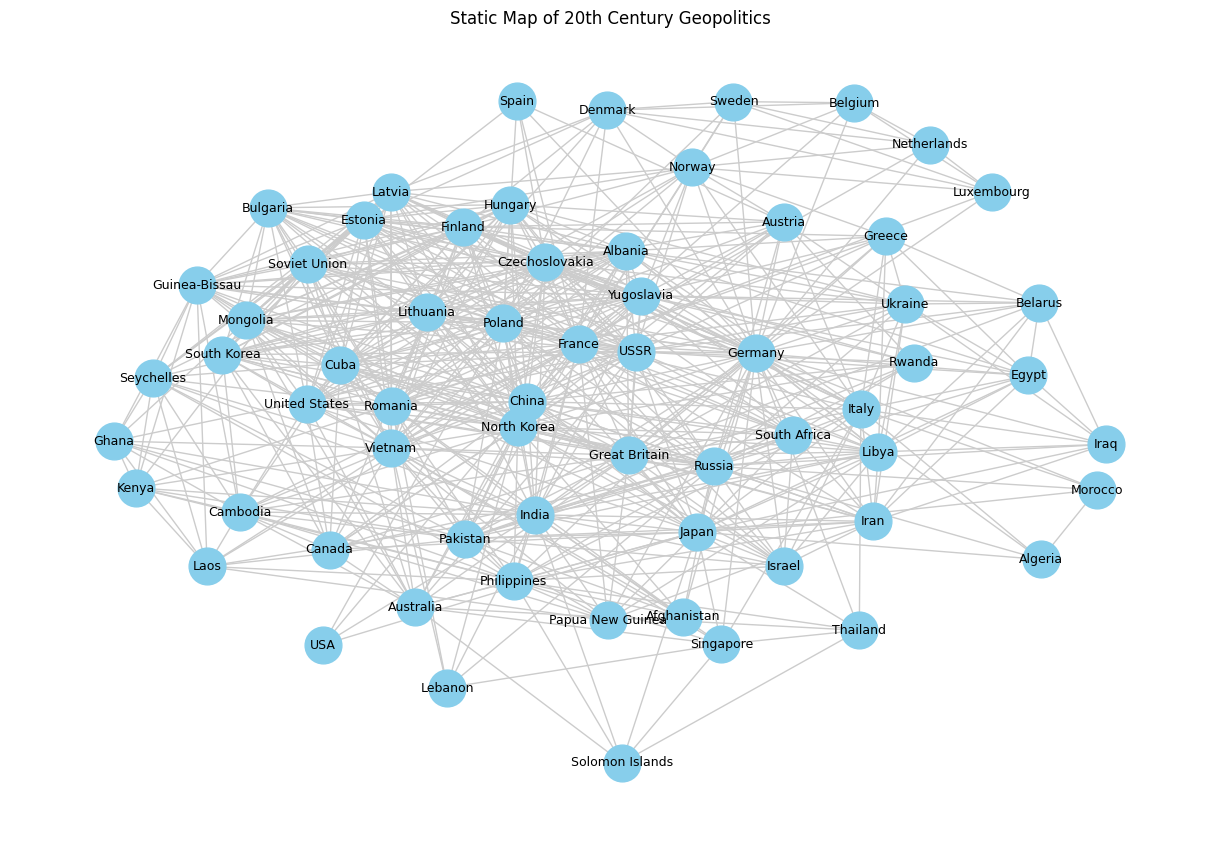

In [16]:
plt.figure(figsize=(12, 8))
pos = nx.kamada_kawai_layout(G)
nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='#cccccc', node_size=700, font_size=9)
plt.title("Static Map of 20th Century Geopolitics")
plt.show()

In [17]:
from pyvis.network import Network

# 1. Initialize the Pyvis Network object
# We set a dark background and white text for a "modern" geopolitical map look
net = Network(height='750px', width='100%', bgcolor='#222222', font_color='white', notebook=True)

# 2. Import the NetworkX graph (G) into Pyvis
net.from_nx(G)

# 3. Configure the "repulsion" physics to prevent flickering and ensure clarity
net.repulsion(node_distance=150, central_gravity=0.01, spring_length=200, spring_strength=0.05)

# 4. Save and generate the HTML file
# This command creates the file in your working directory
net.write_html("interactive_20th_century_network.html")

# 5. Display the graph (if running in a Jupyter Notebook)
net.show("interactive_20th_century_network.html")

interactive_20th_century_network.html


In [18]:
##Interactive Community Detection (Leiden)
# Apply Leiden Algorithm
comms = algorithms.leiden(G)
community_map = {}
for i, group in enumerate(comms.communities):
    for country in group:
        community_map[country] = i

# Map communities to graph attributes
nx.set_node_attributes(G, community_map, 'group')

# Create Pyvis Interactive Graph
net = Network(height='750px', width='100%', bgcolor='#222222', font_color='white', notebook=True)
net.from_nx(G)

# Set node size by degree
degrees = dict(G.degree())
for node in net.nodes:
    node['size'] = degrees[node['id']] * 3

# Physics to prevent flickering
net.repulsion(node_distance=150, spring_length=200)

net.write_html("historical_blocs_leiden.html")
net.show("country_communities.html")

country_communities.html


Reflection: Community Partitions vs. Historical Reality

Does the partition make sense?
Yes, the Leiden algorithm has successfully identified distinct geopolitical clusters that mirror 20th-century historical realities.

The Red Cluster: This clearly represents the Eastern Bloc/Communist influence, grouping the Soviet Union, Romania, Poland, Lithuania, and Vietnam. The density of edges here reflects the tight military and ideological integration of the Warsaw Pact.

The Yellow Cluster: This appears to be the Western Alliance/NATO core, featuring the USA, Great Britain, Italy, and South Africa. Their proximity and shared color represent the capitalistic and security-based ties of the era.

The Green/Blue Clusters: These likely represent the Non-Aligned Movement or regional sub-groups (like Southeast Asia or West Africa). Seeing India and Pakistan near the center suggests their role as major regional powers that often interfaced with both superpowers.

Conclusions about Connections between Communities:

Bridge Nodes: Countries like France (large red node) and India (yellow/green border) act as "bridges." While France is Western, its historical tendency to chart an independent foreign policy (Gaullism) is reflected by its central, interconnected position between the red and yellow blocs.

Global Brokers: High betweenness centrality is visible in nodes that sit in the "valleys" between colors. These countries serve as the primary conduits for diplomatic or economic exchange between otherwise isolated blocs.

Bloc Density: The red cluster is significantly more "dense" (more internal lines) than the yellow, suggesting that while the Western bloc was expansive, the Eastern bloc’s relationships were perhaps more insular and tightly coupled during this period.

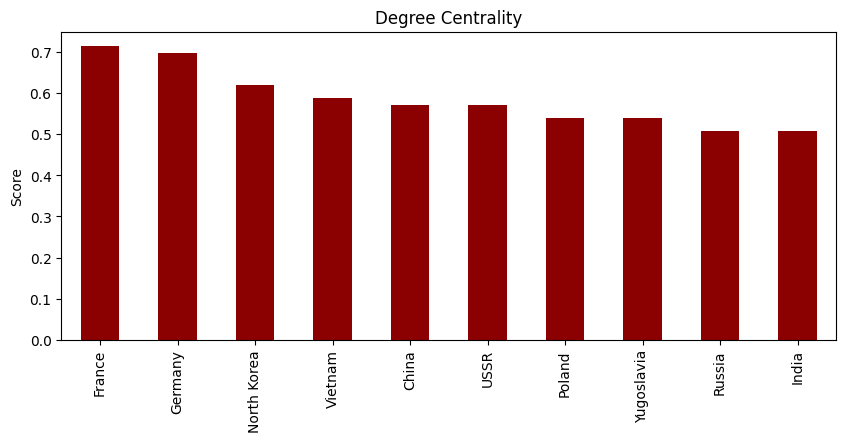

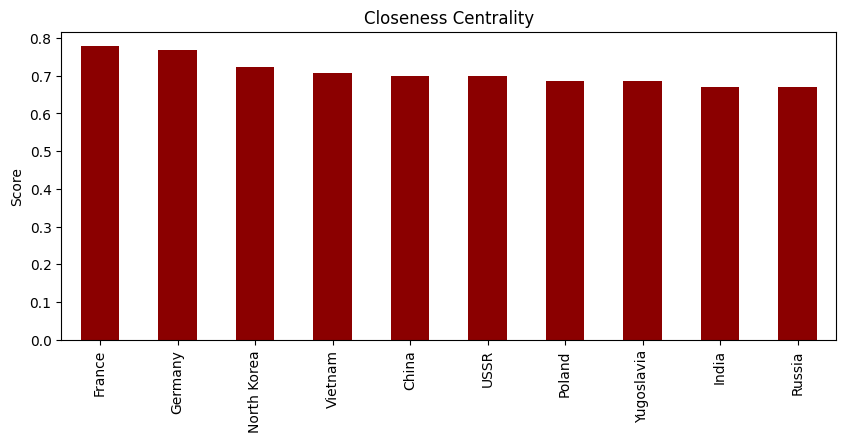

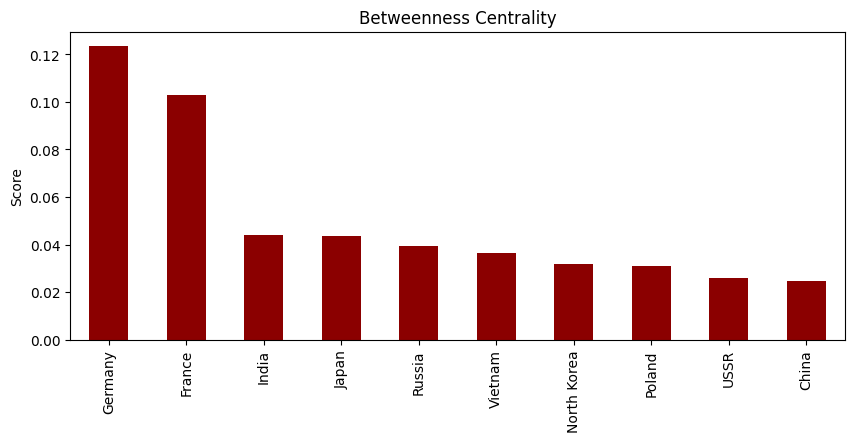

In [13]:
##Centrality Calculations & Plots
# Calculate the three measures
degree = nx.degree_centrality(G)
closeness = nx.closeness_centrality(G)
betweenness = nx.betweenness_centrality(G)

measures = [("Degree Centrality", degree), ("Closeness Centrality", closeness), ("Betweenness Centrality", betweenness)]

for title, data in measures:
    # Convert to sorted DataFrame for plotting
    temp_df = pd.Series(data).sort_values(ascending=False).head(10)
    plt.figure(figsize=(10, 4))
    temp_df.plot(kind='bar', color='darkred')
    plt.title(title)
    plt.ylabel("Score")
    plt.show()

Analysis of Power Dynamics:

Degree Centrality: France and Germany lead this chart, indicating they had the highest number of direct bilateral relationships. This suggests they were the primary diplomatic hubs of the 20th century.

Closeness Centrality: The high scores for France, Germany, and North Korea suggest these nodes were "closest" to all other countries in the network. This means influence or information starting in these nations could spread through the global network most efficiently.

Betweenness Centrality (The "Bridges"): Germany and France have disproportionately high betweenness scores compared to the rest. Historically, this means they acted as vital "gatekeepers" or brokers. If these nodes were removed, the network would likely fracture into isolated Eastern and Western halves.

The "Bridge" Role: Countries like India and Japan also show significant betweenness. This confirms their historical role as mediators or essential trade links that connected different geopolitical communities that might not have communicated directly.